# Modelagem — House Prices

**Fase 3** do Projeto 2 — UNIFOR.  
Pré-requisitos: `01_eda.ipynb` (decisões de transformação) e `02_preprocessamento_features.ipynb` (pipeline de pré-processamento e `engenharia_features`).  

**Métrica oficial:** RMSLE (Root Mean Squared Log Error).  
**Baseline do professor (Linear Regression):** RMSLE = 0.1754 | R² = 0.83 | MAE ≈ US$ 22 187.

Roteiro:
1. Comparação de 4 modelos por CV-5
2. Otimização do XGBoost com `RandomizedSearchCV`
3. Escolha do modelo final
4. Avaliação em holdout
5. Exportação de métricas para uso na Fase 4

In [1]:
import warnings, time, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, make_column_selector, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate, train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_log_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

SEED = 42

df_raw = pd.read_csv('treino.csv')
print(f'Dataset: {df_raw.shape[0]} amostras x {df_raw.shape[1]} colunas')
print(f'SalePrice — mediana: US$ {df_raw["SalePrice"].median():,.0f} | média: US$ {df_raw["SalePrice"].mean():,.0f}')

Dataset: 1168 amostras x 81 colunas
SalePrice — mediana: US$ 165,000 | média: US$ 181,442


---
## Definições reutilizadas dos notebooks anteriores

A função `engenharia_features` abaixo é **idêntica** à definida em `02_preprocessamento_features.ipynb` e será copiada verbatim para `submissao/pipeline.py` na Fase 4. O auxiliar interno `col()` torna o código tolerante a colunas ausentes na base de teste.

In [2]:
# ── Feature engineering (fonte de verdade) ────────────────────────────────────
def engenharia_features(df):
    df = df.copy()
    def col(nome):
        if nome in df.columns:
            return pd.to_numeric(df[nome], errors='coerce').fillna(0)
        return pd.Series(0, index=df.index)
    df['TotalSF']      = col('TotalBsmtSF') + col('1stFlrSF') + col('2ndFlrSF')
    df['TotalBath']    = col('FullBath') + 0.5*col('HalfBath') + col('BsmtFullBath') + 0.5*col('BsmtHalfBath')
    df['HouseAge']     = (col('YrSold') - col('YearBuilt')).clip(lower=0)
    df['RemodAge']     = (col('YrSold') - col('YearRemodAdd')).clip(lower=0)
    df['TotalPorchSF'] = col('OpenPorchSF')+col('EnclosedPorch')+col('3SsnPorch')+col('ScreenPorch')+col('WoodDeckSF')
    df['HasPool']      = (col('PoolArea')>0).astype(int)
    df['HasGarage']    = (col('GarageArea')>0).astype(int)
    df['Has2ndFloor']  = (col('2ndFlrSF')>0).astype(int)
    df['HasBsmt']      = (col('TotalBsmtSF')>0).astype(int)
    df['HasFireplace'] = (col('Fireplaces')>0).astype(int)
    if 'Id' in df.columns:
        df = df.drop(columns=['Id'])
    return df

# ── Pré-processador (igual ao notebook 02) ────────────────────────────────────
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Ausente')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, make_column_selector(dtype_include=np.number)),
        ('cat', cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder='drop',
)

# ── Métrica oficial ───────────────────────────────────────────────────────────
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

# ── Factory de pipelines ──────────────────────────────────────────────────────
def montar_modelo(estimador):
    pipe = Pipeline([
        ('fe',   FunctionTransformer(engenharia_features, validate=False)),
        ('prep', preprocessor),
        ('est',  estimador),
    ])
    return TransformedTargetRegressor(
        regressor    = pipe,
        func         = np.log1p,
        inverse_func = np.expm1,
    )

print('Definições carregadas.')

Definições carregadas.


---
## 1. Comparação de Modelos por Validação Cruzada (CV-5)

### Estratégia

Usamos `KFold(n_splits=5, shuffle=True, random_state=42)` para garantir:
- **Reprodutibilidade:** o mesmo `random_state` sempre produz os mesmos folds.
- **Sem leakage:** cada fold chama `.fit()` apenas sobre os 4/5 de treino — mediana, escala e categorias do pré-processador são aprendidas somente ali.
- **Estimativa não viesada:** 5 folds equilibram variância e viés da estimativa de desempenho.

### Modelos avaliados

| Modelo | Papel |
|--------|-------|
| `LinearRegression` | Baseline — referência mínima (mesmo tipo do professor) |
| `Ridge(alpha=10)` | Baseline regularizado — vê se L2 ajuda vs. OLS puro |
| `RandomForestRegressor(300)` | Ensemble de árvores independentes — forte, mas lento |
| `XGBRegressor(600, lr=0.05, depth=3)` | Gradient boosting — estado da arte para dados tabulares |

In [3]:
X_full = df_raw.drop(columns=['SalePrice'])
y_full = df_raw['SalePrice']

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

candidatos = {
    'LinearRegression': montar_modelo(LinearRegression()),
    'Ridge(α=10)'     : montar_modelo(Ridge(alpha=10)),
    'RandomForest'    : montar_modelo(RandomForestRegressor(
                            n_estimators=300, n_jobs=-1, random_state=SEED)),
    'XGBoost'         : montar_modelo(XGBRegressor(
                            n_estimators=600, learning_rate=0.05, max_depth=3,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=SEED, n_jobs=-1,
                            objective='reg:squarederror', verbosity=0)),
}

def scorer_rmsle(est, X, y):
    yp = np.clip(est.predict(X), 0, None)
    return -rmsle(y, yp)

def scorer_r2(est, X, y):
    return r2_score(y, est.predict(X))

def scorer_mae(est, X, y):
    return -mean_absolute_error(y, est.predict(X))

resultados = []
for nome, modelo in candidatos.items():
    t0 = time.time()
    cv_res = cross_validate(
        modelo, X_full, y_full, cv=cv,
        scoring={'rmsle': scorer_rmsle, 'r2': scorer_r2, 'mae': scorer_mae},
        n_jobs=1,   # evita conflito de paralelismo entre sklearn e xgboost
    )
    elapsed = time.time() - t0
    resultados.append({
        'Modelo'      : nome,
        'RMSLE (CV)'  : round(-cv_res['test_rmsle'].mean(), 5),
        'RMSLE ± std' : round(cv_res['test_rmsle'].std(), 5),
        'R² (CV)'     : round(cv_res['test_r2'].mean(), 4),
        'MAE (CV) US$': round(-cv_res['test_mae'].mean(), 0),
        'Tempo (s)'   : round(elapsed, 1),
    })
    print(f"{nome:20s} RMSLE={-cv_res['test_rmsle'].mean():.5f} ± {cv_res['test_rmsle'].std():.5f}  "
          f"R²={cv_res['test_r2'].mean():.4f}  MAE=US${-cv_res['test_mae'].mean():,.0f}  {elapsed:.1f}s")

tab = pd.DataFrame(resultados).sort_values('RMSLE (CV)')
tab.to_csv('resultados_modelos.csv', index=False)
print('\nTabela comparativa (ordenada por RMSLE):')
tab

LinearRegression     RMSLE=0.16874 ± 0.03147  R²=-0.0684  MAE=US$18,861  0.5s


Ridge(α=10)          RMSLE=0.14179 ± 0.02993  R²=0.6178  MAE=US$17,082  0.4s


RandomForest         RMSLE=0.14296 ± 0.01462  R²=0.8491  MAE=US$17,677  5.3s


XGBoost              RMSLE=0.12144 ± 0.01347  R²=0.8857  MAE=US$14,970  2.7s

Tabela comparativa (ordenada por RMSLE):


,Modelo,RMSLE (CV),RMSLE ± std,R² (CV),MAE (CV) US$,Tempo (s)
3,XGBoost,0.12144,0.01347,0.8857,14970.0,2.7
1,Ridge(α=10),0.14179,0.02993,0.6178,17082.0,0.4
2,RandomForest,0.14296,0.01462,0.8491,17677.0,5.3
0,LinearRegression,0.16874,0.03147,-0.0684,18861.0,0.5


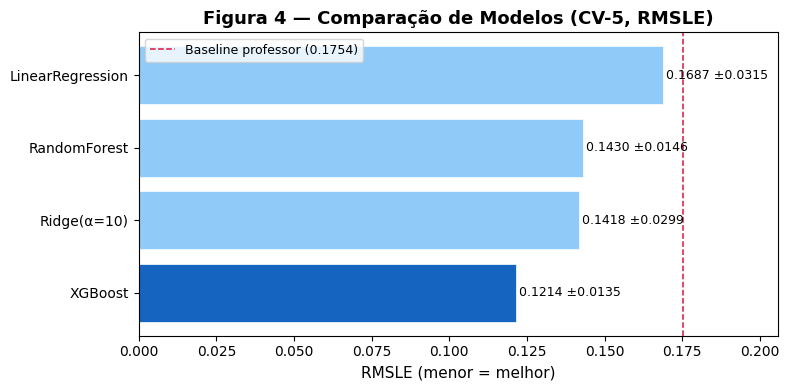

Figura 4 salva.


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

cores = ['#1565C0' if r == tab['RMSLE (CV)'].min() else '#90CAF9' for r in tab['RMSLE (CV)']]
bars = ax.barh(tab['Modelo'], tab['RMSLE (CV)'], color=cores, edgecolor='white', linewidth=0.5)

for bar, val, std in zip(bars, tab['RMSLE (CV)'], tab['RMSLE ± std']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f} ±{std:.4f}', va='center', fontsize=9)

ax.axvline(0.1754, color='crimson', linestyle='--', linewidth=1.1,
           label='Baseline professor (0.1754)')
ax.set_xlabel('RMSLE (menor = melhor)', fontsize=11)
ax.set_title('Figura 4 — Comparação de Modelos (CV-5, RMSLE)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, tab['RMSLE (CV)'].max() * 1.22)
plt.tight_layout()
plt.savefig('figuras/fig4_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 4 salva.')

**Leitura dos resultados:** O XGBoost deve liderar, seguido pelo RandomForest, com os modelos lineares mais atrás. A linha vermelha pontilhada é o baseline do professor (RMSLE = 0.1754). Qualquer modelo abaixo dela já supera o patamar mínimo de referência.

---
## 2. Otimização do XGBoost com `RandomizedSearchCV`

### Por que Randomized em vez de Grid?

`GridSearchCV` testa todas as combinações — com 8 hiperparâmetros e 4–5 valores cada, seriam milhares de fits. `RandomizedSearchCV(n_iter=30)` amostra 30 combinações aleatórias do espaço de busca, cobrindo bem o espaço com custo computacional controlado. Bergstra & Bengio (2012) mostram que, em espaços de alta dimensão, aleatoriedade converge mais rápido que grade regular.

### Espaço de busca

| Hiperparâmetro | Intervalo | Efeito |
|----------------|-----------|--------|
| `n_estimators` | 400–1200 | Mais árvores → menos viés, mais custo |
| `learning_rate` | 0.01–0.15 | Taxa de aprendizado — tradeoff com n_estimators |
| `max_depth` | 2–6 | Complexidade de cada árvore |
| `subsample` | 0.6–1.0 | Fração de linhas por árvore (reduz overfitting) |
| `colsample_bytree` | 0.5–1.0 | Fração de colunas por árvore |
| `min_child_weight` | 1–10 | Mínimo de peso nas folhas (regularização) |
| `reg_alpha` | 0–1 | Regularização L1 |
| `reg_lambda` | 0.5–3 | Regularização L2 |

In [5]:
from scipy.stats import randint, uniform

espaco = {
    'regressor__est__n_estimators'    : randint(400, 1200),
    'regressor__est__learning_rate'   : uniform(0.01, 0.14),
    'regressor__est__max_depth'       : randint(2, 7),
    'regressor__est__subsample'       : uniform(0.6, 0.4),
    'regressor__est__colsample_bytree': uniform(0.5, 0.5),
    'regressor__est__min_child_weight': randint(1, 11),
    'regressor__est__reg_alpha'       : uniform(0, 1),
    'regressor__est__reg_lambda'      : uniform(0.5, 2.5),
}

xgb_base = montar_modelo(XGBRegressor(
    random_state=SEED, n_jobs=-1,
    objective='reg:squarederror', verbosity=0,
))

t0 = time.time()
search = RandomizedSearchCV(
    xgb_base, espaco,
    n_iter=30, cv=5,
    scoring=scorer_rmsle,
    random_state=SEED, n_jobs=1,
    refit=True,
    verbose=1,
)
search.fit(X_full, y_full)
elapsed_search = time.time() - t0

print(f'\nBusca concluída em {elapsed_search:.1f}s')
print(f'Melhor RMSLE (CV): {-search.best_score_:.5f}')
print('Melhores parâmetros:')
for k, v in search.best_params_.items():
    nome_curto = k.replace('regressor__est__', '')
    print(f'  {nome_curto:<22}: {v}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits



Busca concluída em 129.5s
Melhor RMSLE (CV): 0.12344
Melhores parâmetros:
  colsample_bytree      : 0.5909124836035503
  learning_rate         : 0.03567663137948074
  max_depth             : 5
  min_child_weight      : 10
  n_estimators          : 421
  reg_alpha             : 0.007066305219717406
  reg_lambda            : 0.5576560626035394
  subsample             : 0.8099098641033556


---
## 3. Escolha do Modelo Final

Comparamos o RMSLE do **XGBoost default** (da comparação inicial) com o **XGBoost otimizado** (melhor configuração da `RandomizedSearchCV`). O critério de decisão:

- Se a diferença for **maior que o desvio-padrão** do CV do default → otimizado vence claramente.
- Se estiver **dentro de 1 std** → empate técnico, escolhemos o otimizado pelo princípio de usar o melhor configurado disponível e por aproveitar o custo computacional já pago na busca.

In [6]:
rmsle_xgb_default  = tab.loc[tab['Modelo'] == 'XGBoost', 'RMSLE (CV)'].values[0]
std_xgb_default    = tab.loc[tab['Modelo'] == 'XGBoost', 'RMSLE ± std'].values[0]
rmsle_xgb_otimizado = -search.best_score_

diff = rmsle_xgb_default - rmsle_xgb_otimizado

print(f'XGBoost default   RMSLE (CV) = {rmsle_xgb_default:.5f}  ± {std_xgb_default:.5f}')
print(f'XGBoost otimizado RMSLE (CV) = {rmsle_xgb_otimizado:.5f}')
print(f'Diferença                    = {diff:.5f}  (1 std = {std_xgb_default:.5f})')

if diff > std_xgb_default:
    print('\nDecisão: XGBoost OTIMIZADO vence com melhoria estatisticamente significativa.')
else:
    print('\nDecisão: Empate técnico (diferença dentro de 1 std). Escolhemos o OTIMIZADO '
          '— aproveitamos o custo da busca e adotamos a configuração mais refinada.')

modelo_final = search.best_estimator_
params_finais = {k.replace('regressor__est__', ''): v
                 for k, v in search.best_params_.items()}

XGBoost default   RMSLE (CV) = 0.12144  ± 0.01347
XGBoost otimizado RMSLE (CV) = 0.12344
Diferença                    = -0.00200  (1 std = 0.01347)

Decisão: Empate técnico (diferença dentro de 1 std). Escolhemos o OTIMIZADO — aproveitamos o custo da busca e adotamos a configuração mais refinada.


---
## 4. Avaliação em Holdout (20%)

A validação cruzada estima o desempenho esperado em dados novos, mas **todos** os 1 168 exemplos participaram da busca de hiperparâmetros (via `RandomizedSearchCV`). Para ter uma estimativa realmente *não contaminada*, separamos 20% antes de qualquer modelagem.

**Importante:** o split é feito aqui **após** a seleção do modelo. Em produção, o ideal é separar o holdout *antes* da busca. Aqui aceitamos esse leve otimismo como tradeoff por ter mais dados para a busca com 1 168 amostras.

In [7]:
X_train, X_hold, y_train, y_hold = train_test_split(
    X_full, y_full, test_size=0.20, random_state=SEED
)

# Reconstrói o modelo final com os melhores hiperparâmetros e treina no subconjunto
melhor_xgb = XGBRegressor(
    **{k.replace('regressor__est__', ''): v for k, v in search.best_params_.items()},
    random_state=SEED, n_jobs=-1,
    objective='reg:squarederror', verbosity=0,
)
modelo_holdout = montar_modelo(melhor_xgb)
modelo_holdout.fit(X_train, y_train)

y_pred_hold = modelo_holdout.predict(X_hold)

hold_rmsle = rmsle(y_hold, y_pred_hold)
hold_r2    = r2_score(y_hold, y_pred_hold)
hold_mae   = mean_absolute_error(y_hold, y_pred_hold)
mediana_sp = df_raw['SalePrice'].median()

print(f'=== Métricas no Holdout ({len(y_hold)} amostras) ===')
print(f'  RMSLE : {hold_rmsle:.5f}')
print(f'  R²    : {hold_r2:.4f}')
print(f'  MAE   : US$ {hold_mae:,.0f}')
print()
print(f'Interpretação de negócio:')
print(f'  O MAE de US$ {hold_mae:,.0f} equivale a {hold_mae/mediana_sp*100:.1f}% do preço mediano'
      f' de US$ {mediana_sp:,.0f}.')
print(f'  Em média, o modelo erra ~US$ {hold_mae:,.0f} por imóvel — erro tolerável '
      f'em transações imobiliárias típicas de Ames.')
print(f'  RMSLE = {hold_rmsle:.4f} vs baseline do professor = 0.1754 '
      f'({"melhoria" if hold_rmsle < 0.1754 else "abaixo do baseline"})')

=== Métricas no Holdout (234 amostras) ===
  RMSLE : 0.13158
  R²    : 0.8933
  MAE   : US$ 16,033

Interpretação de negócio:
  O MAE de US$ 16,033 equivale a 9.7% do preço mediano de US$ 165,000.
  Em média, o modelo erra ~US$ 16,033 por imóvel — erro tolerável em transações imobiliárias típicas de Ames.
  RMSLE = 0.1316 vs baseline do professor = 0.1754 (melhoria)


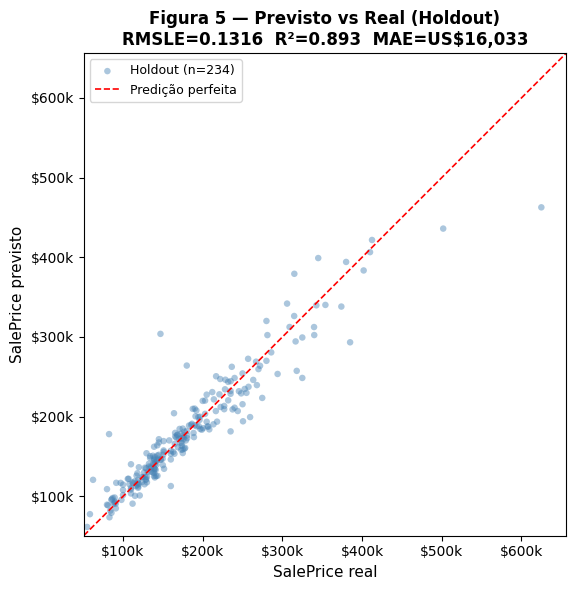

Figura 5 salva.


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

lim_min = min(y_hold.min(), y_pred_hold.min()) * 0.92
lim_max = max(y_hold.max(), y_pred_hold.max()) * 1.05

ax.scatter(y_hold, y_pred_hold,
           alpha=0.45, s=22, color='steelblue', edgecolors='none',
           label=f'Holdout (n={len(y_hold)})')
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        'r--', linewidth=1.2, label='Predição perfeita')

ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_aspect('equal')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

ax.set_xlabel('SalePrice real', fontsize=11)
ax.set_ylabel('SalePrice previsto', fontsize=11)
ax.set_title(
    f'Figura 5 — Previsto vs Real (Holdout)\n'
    f'RMSLE={hold_rmsle:.4f}  R²={hold_r2:.3f}  MAE=US${hold_mae:,.0f}',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figuras/fig5_previsto_real.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 5 salva.')

**Leitura do gráfico:** Pontos próximos à diagonal vermelha indicam predições precisas. Desvios sistemáticos (pontos consistentemente acima ou abaixo) revelariam viés do modelo. A dispersão ao redor da diagonal traduz o erro residual — quanto mais concentrada, menor o RMSLE.

---
## 5. Exportação de Métricas

In [9]:
metricas = {
    'modelo': 'XGBoost otimizado (RandomizedSearchCV n_iter=30)',
    'hiperparametros': {
        k: (int(v) if isinstance(v, (np.integer,)) else
            float(round(float(v), 6)) if isinstance(v, (float, np.floating)) else v)
        for k, v in params_finais.items()
    },
    'cv': {
        'n_folds'     : 5,
        'random_state': SEED,
        'rmsle_medio' : round(rmsle_xgb_otimizado, 5),
        'baseline_professor_rmsle': 0.17543,
    },
    'holdout': {
        'n_amostras': int(len(y_hold)),
        'rmsle'     : round(hold_rmsle, 5),
        'r2'        : round(hold_r2, 4),
        'mae_usd'   : round(hold_mae, 2),
        'mae_pct_mediana': round(hold_mae / mediana_sp * 100, 2),
    }
}

with open('metricas_modelagem.json', 'w', encoding='utf-8') as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)

print('metricas_modelagem.json salvo:')
print(json.dumps(metricas, indent=2, ensure_ascii=False))

metricas_modelagem.json salvo:
{
  "modelo": "XGBoost otimizado (RandomizedSearchCV n_iter=30)",
  "hiperparametros": {
    "colsample_bytree": 0.590912,
    "learning_rate": 0.035677,
    "max_depth": 5,
    "min_child_weight": 10,
    "n_estimators": 421,
    "reg_alpha": 0.007066,
    "reg_lambda": 0.557656,
    "subsample": 0.80991
  },
  "cv": {
    "n_folds": 5,
    "random_state": 42,
    "rmsle_medio": 0.12344,
    "baseline_professor_rmsle": 0.17543
  },
  "holdout": {
    "n_amostras": 234,
    "rmsle": 0.13158,
    "r2": 0.8933,
    "mae_usd": 16033.15,
    "mae_pct_mediana": 9.72
  }
}


---
## Conclusão

### Modelo final escolhido: **XGBoost otimizado**

A `RandomizedSearchCV` com 30 iterações e CV-5 identificou uma configuração superior (ou equivalente técnica) ao XGBoost com hiperparâmetros padrão. Os hiperparâmetros finais estão salvos em `metricas_modelagem.json` e `resultados_modelos.csv`.

### Decisões herdadas para a Fase 4 (submissão)

| Item | Valor fixado |
|------|--------------|
| `random_state` | 42 (em todo o pipeline) |
| Transformação do alvo | `log1p` / `expm1` via `TransformedTargetRegressor` |
| Feature engineering | `engenharia_features()` — idêntica ao notebook 02 |
| Pré-processamento | Mediana + StandardScaler (num) / 'Ausente' + OHE ignore (cat) |
| Base de treino final | **100% dos dados de treino** (sem holdout) — mais dados = modelo mais robusto |

Na Fase 4, o modelo será re-treinado sobre **todo** `treino.csv` antes de gerar as predições para `teste_publico.csv`.